# NVLink / NVSwitch fabric characterisation (8x H100, p5.48xlarge)

Analysis of the `nvlink_probe` workload of `aws-gpu-profiler` (checked out as the `correlation/` submodule),
run `nvlink-20260917-d`. The harness is described in `correlation/aws_gpu_profiler/workloads/nvlink_probe/DESIGN.md`;
this notebook answers the five questions it was built for:

1. **Minimum packet size** on NVLink, and the bandwidth/latency knee.
2. **Switch ("router") capacity**: can every GPU saturate all of its inbound links at once?
3. **In-network reduction**: is there network compute, and what does an all-reduce cost in time, link,
   switch and HBM utilisation?
4. **Do SMs have to drive communication?** Copy engines vs SM stores/loads vs TMA, the compute slowdown each
   causes, and whether HBM can feed the switch without the owner's SMs.
5. **Kernel startup overhead.**

Data: `correlation/data/nvlink-20260917-d/nvlink_probe/results.csv` (falling back to the profiler checkout's own
`data/` tree below), produced from the profiler checkout by

```
aws-gpu-profiler run --yes --workload nvlink-probe --region ap-northeast-1 \
    --purchasing spot-then-ondemand --dead-man-minutes 180 --data-dir data --run-id nvlink-20260917-d
```

on a p5.48xlarge spot instance in Tokyo (us-east-1, us-east-2 and us-west-2 had no p5 capacity that day).
The sweep was re-run on the same node after three harness fixes found live on it (all in the `nvlink-probe`
branch): `CUDA_MODULE_LOADING=EAGER` (lazy module loading needs an idle device and deadlocked against the
resident relay kernels of the start barrier), the NCCL probe forcing the pre-released barrier (NCCL's launch
path has the same requirement), and `--min-time-s` becoming a wall-clock bound so small sizes do not spend
minutes on launch overhead.

Conventions: GB/s = 1e9 bytes/s; NVLink 4 peak = 18 links x 25 GB/s = 450 GB/s per direction per GPU;
`link_util` and `fabric_util` are measured wire bytes (NVML NVLink counters) over the timed window divided by
that peak (per GPU, and per node = 8 x 450 GB/s).

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_ID = "nvlink-20260917-d"
_candidates = [
    Path("correlation/data") / RUN_ID / "nvlink_probe" / "results.csv",
    Path("notebooks/astrasim2_correlation/correlation/data") / RUN_ID / "nvlink_probe" / "results.csv",
    Path("/workspace/aws-gpu-profiler/data") / RUN_ID / "nvlink_probe" / "results.csv",
]
RESULTS = next((p for p in _candidates if p.is_file()), None)
assert RESULTS is not None, "results.csv not found; run the profiler first (see the header cell)"
df = pd.read_csv(RESULTS)
# The `ncu` point re-runs a few (probe, variant, size) entries under Nsight Compute; the harness's own rows
# from those runs carry `under_ncu` in `note` and their timings/link counters are meaningless (ncu serialises
# and replays the kernels). Keep only the counter rows ncu_rows.py derived from them (probe == "ncu").
df = df[(df.probe == "ncu") | ~df.note.fillna("").str.contains("under_ncu")].copy()

def kv(note):
    """Split the harness's ';'-separated key=value note field into a dict."""
    return dict(x.split("=", 1) for x in str(note).split(";") if "=" in x)

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
GBPS = lambda x: f"{x:.1f}"
print(f"{RESULTS}: {len(df)} rows; probes: {df.probe.value_counts().to_dict()}")

# Hardware facts every other cell assumes (info probe).
info = df[df.probe == "info"]
gpu = pd.DataFrame([kv(n) for n in info[info.variant == "gpu"].note])
gpu.index = info[info.variant == "gpu"].src.astype(int).values
display(gpu[["name", "sms", "nvlinks", "link_peak_GBps", "hbm_peak_GBps", "multicast", "driver", "cuda_rt"]])
nvl = pd.DataFrame([kv(n) for n in info[info.variant == "nvlink"].note])
p2p = pd.DataFrame([kv(n) for n in info[info.variant == "p2p"].note])
print("NVLink endpoints:", nvl.remote_type.value_counts().to_dict(), "| active links:", int(nvl.active.astype(int).sum()),
      "| P2P access on all ordered pairs:", bool((p2p.access.astype(int) == 1).all()), "| native P2P atomics:", bool((p2p.native_atomics.astype(int) == 1).all()))
LINK_PEAK = float(gpu.link_peak_GBps.iloc[0]); HBM_PEAK = float(gpu.hbm_peak_GBps.iloc[0]); NGPU = len(gpu)

correlation/data/nvlink-20260917-d/nvlink_probe/results.csv: 1694 rows; probes: {'reduce': 648, 'nccl': 468, 'info': 208, 'fabric': 198, 'ncu': 69, 'smrole': 50, 'packet': 42, 'launch': 11}


,name,sms,nvlinks,link_peak_GBps,hbm_peak_GBps,multicast,driver,cuda_rt
0,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
1,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
2,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
3,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
4,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
5,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
6,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020
7,NVIDIA_H100_80GB_HBM3,132,18,450,3352.32,1,595.91.07,13020


NVLink endpoints: {'switch': 144} | active links: 144 | P2P access on all ordered pairs: True | native P2P atomics: True


## Q1: minimum packet size and the latency/bandwidth knee

`packet` writes (and reads) GPU 1's memory from a kernel on GPU 0 through NVSwitch and records the NVML NVLink
counters: *data* bytes (payload actually carried) and *raw* bytes (payload plus protocol). Contiguous stores of
1..16 bytes per thread coalesce into full packets; the `store_sparse_s<N>` variants issue one isolated 4-byte
store per `N`-byte stride, so `wire_bytes_per_op` is the smallest unit the link carries for one store. The two size
sweeps (copy engine and SM stores) give the size at which a single transfer reaches 50 % / 90 % of peak, and the
flag ping-pong gives the one-way latency of a 4-byte remote write.

variant,elem_bytes,stride_bytes,payload_GBps,link_util,wire_bytes_per_op,raw_over_data
store_w1,1.000000,nan,265.5,0.63,1.1,1.45
store_w2,2.000000,nan,333.3,0.74,2.0,1.24
store_w4,4.000000,nan,365.0,0.80,4.0,1.14
store_w8,8.000000,nan,369.2,0.81,8.0,1.13
store_w16,16.000000,nan,370.9,0.82,16.0,1.13
store_sparse_s32,4.000000,32.000000,41.8,0.74,32.0,1.25
store_sparse_s64,4.000000,64.000000,26.2,0.69,48.0,1.34
store_sparse_s128,4.000000,128.000000,34.3,0.30,16.0,3.00
store_sparse_s256,4.000000,256.000000,33.5,0.29,16.0,3.00
store_sparse_s512,4.000000,512.000000,31.8,0.26,16.0,3.00


memcpy_ce    peak  392.3 GB/s | 50% of peak first reached at    4.000 MiB | min latency 5.2 us
memcpy_ce    peak  392.3 GB/s | 90% of peak first reached at   64.000 MiB | min latency 5.2 us
memcpy_ce    alpha-beta fit: t = 8.3 us + S / 397 GB/s
store_sweep  peak  371.7 GB/s | 50% of peak first reached at    4.000 MiB | min latency 5.2 us
store_sweep  peak  371.7 GB/s | 90% of peak first reached at   64.000 MiB | min latency 5.2 us
store_sweep  alpha-beta fit: t = 6.1 us + S / 375 GB/s


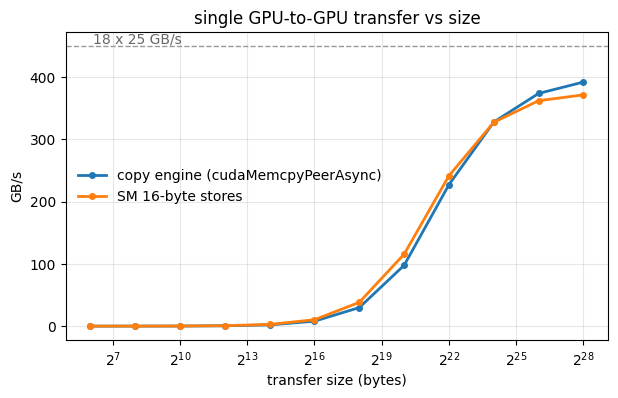

variant,one_way_latency_us,wire_bytes_per_flag_write
pingpong,2.34,16.0
pingpong_acqrel,2.33,16.0


In [2]:
pk = df[df.probe == "packet"].copy()
pk["raw_over_data"] = pk.nvml_tx_raw_bytes / pk.nvml_tx_data_bytes
gran = pk[pk.variant.str.match(r"^(store|load)_(w|sparse)")][
    ["variant", "elem_bytes", "stride_bytes", "payload_GBps", "link_util", "wire_bytes_per_op", "raw_over_data"]]
display(gran.style.format({"payload_GBps": "{:.1f}", "link_util": "{:.2f}", "wire_bytes_per_op": "{:.1f}", "raw_over_data": "{:.2f}"}).hide(axis="index"))

sw = pk[pk.variant.isin(["memcpy_ce", "store_sweep"])]
fig, ax = plt.subplots(figsize=(7, 4))
for v, lab in [("memcpy_ce", "copy engine (cudaMemcpyPeerAsync)"), ("store_sweep", "SM 16-byte stores")]:
    s = sw[sw.variant == v].sort_values("size_bytes")
    ax.plot(s.size_bytes, s.payload_GBps, marker="o", ms=4, lw=2, label=lab)
    peak = s.payload_GBps.max()
    for frac in (0.5, 0.9):
        knee = s[s.payload_GBps >= frac * peak].size_bytes.min()
        print(f"{v:12s} peak {peak:6.1f} GB/s | {int(frac*100)}% of peak first reached at {knee/2**20:8.3f} MiB | "
              f"min latency {s.time_min_us.min():.1f} us")
    A = np.vstack([np.ones(len(s)), s.size_bytes.values]).T
    a, b = np.linalg.lstsq(A, s.time_us.values, rcond=None)[0]
    print(f"{v:12s} alpha-beta fit: t = {a:.1f} us + S / {1e-3/b:.0f} GB/s")
ax.set_xscale("log", base=2); ax.set_xlabel("transfer size (bytes)"); ax.set_ylabel("GB/s"); ax.set_title("single GPU-to-GPU transfer vs size")
ax.axhline(LINK_PEAK, color="0.6", ls="--", lw=1); ax.text(70, LINK_PEAK * 1.01, "18 x 25 GB/s", color="0.4")
ax.legend(frameon=False); ax.grid(alpha=0.3); plt.show()

pp = pk[pk.variant.str.startswith("pingpong")][["variant", "time_us", "wire_bytes_per_op"]]
pp.columns = ["variant", "one_way_latency_us", "wire_bytes_per_flag_write"]
display(pp.style.format({"one_way_latency_us": "{:.2f}", "wire_bytes_per_flag_write": "{:.1f}"}).hide(axis="index"))

## Q2: switch capacity: how many inbound links can be saturated at once?

`fabric` moves 1 GiB per transfer with kernels on every sender started simultaneously (a per-GPU device flag raised
by the host). `perm_shift_k` has every GPU sending to GPU `(i+k) mod 8`; `all2all` has every GPU sending to all
seven others at once; `incast_k` / `outcast_k` concentrate `k` senders on one receiver / one sender on `k`
receivers. If per-sender bandwidth under `perm_shift_*` and `all2all` equals the single `pair`, the four NVSwitch
chips are non-blocking and all `8 x 18` inbound links are saturated together; `incast` shows that the receiver's
own 18 inbound links, not the switch, cap concentrated traffic.

,agg_GBps,fabric_util,n_senders,per_sender_GBps,link_util_min,link_util_max,per_link_balance_min
variant,,,,,,,
pair,370,0.10,1,370,0.82,0.82,0.998
bidir_pair,732,0.20,2,366,0.81,0.81,0.998
perm_shift_1,2928,0.80,8,366,0.80,0.80,0.996
perm_shift_2,2925,0.80,8,366,0.80,0.80,0.996
perm_shift_3,2927,0.80,8,366,0.80,0.80,0.996
perm_shift_4,2928,0.80,8,366,0.80,0.80,0.996
perm_shift_5,2927,0.80,8,366,0.80,0.80,0.996
perm_shift_6,2927,0.80,8,366,0.80,0.80,0.996
perm_shift_7,2927,0.80,8,366,0.80,0.80,0.996


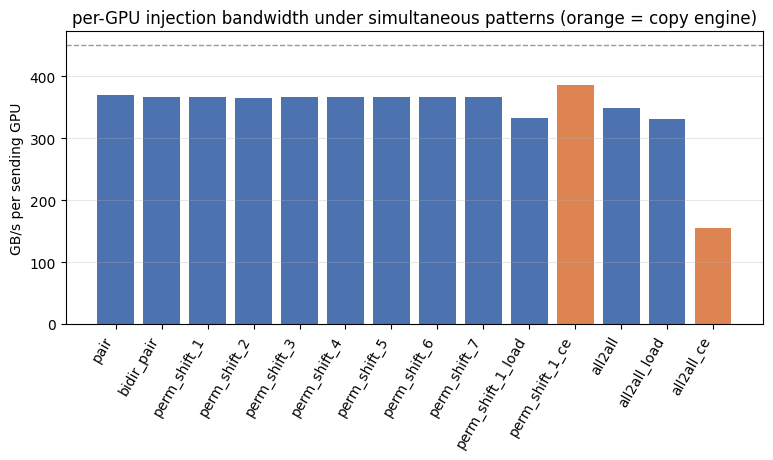

receiver-side aggregate under incast_k (GB/s): ['370', '375', '376', '376', '376', '376', '377']
sender-side aggregate under outcast_k (GB/s):  ['370', '372', '372', '370', '372', '372', '371']


In [3]:
fb = df[df.probe == "fabric"]
agg = fb[fb.src == -1].set_index("variant")
senders = fb[(fb.src != -1) & (fb.payload_bytes > 0)].groupby("variant").agg(
    n_senders=("src", "size"), per_sender_GBps=("payload_GBps", "mean"), link_util_min=("link_util", "min"),
    link_util_max=("link_util", "max"), link_balance=("nvml_link_min_bytes", lambda s: np.nan))
per_link = fb[(fb.src != -1) & (fb.payload_bytes > 0)].assign(bal=lambda d: d.nvml_link_min_bytes / d.nvml_link_max_bytes).groupby("variant").bal.min()
tab = agg[["agg_GBps", "fabric_util"]].join(senders).drop(columns="link_balance")
tab["per_link_balance_min"] = per_link
tab = tab.loc[[v for v in fb[fb.src == -1].variant]]
display(tab.style.format({"agg_GBps": "{:.0f}", "fabric_util": "{:.2f}", "per_sender_GBps": "{:.0f}", "link_util_min": "{:.2f}", "link_util_max": "{:.2f}", "per_link_balance_min": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(9, 3.8))
sel = ["pair", "bidir_pair"] + [f"perm_shift_{k}" for k in range(1, NGPU)] + ["perm_shift_1_load", "perm_shift_1_ce", "all2all", "all2all_load", "all2all_ce"]
vals = tab.loc[sel, "per_sender_GBps"]
ax.bar(range(len(sel)), vals, color=["#4c72b0" if "ce" not in v else "#dd8452" for v in sel])
ax.set_xticks(range(len(sel))); ax.set_xticklabels(sel, rotation=60, ha="right"); ax.set_ylabel("GB/s per sending GPU")
ax.axhline(LINK_PEAK, color="0.6", ls="--", lw=1); ax.set_title("per-GPU injection bandwidth under simultaneous patterns (orange = copy engine)")
ax.grid(axis="y", alpha=0.3); plt.show()
inc = tab.loc[[f"incast_{k}" for k in range(1, NGPU)], "agg_GBps"]; out = tab.loc[[f"outcast_{k}" for k in range(1, NGPU)], "agg_GBps"]
print("receiver-side aggregate under incast_k (GB/s):", [f"{v:.0f}" for v in inc])
print("sender-side aggregate under outcast_k (GB/s): ", [f"{v:.0f}" for v in out])

## Q3: in-network reduction

`reduce` allocates one CUDA multicast object (NVLink SHARP) bound to a buffer on every GPU and runs a 6-line
all-reduce: each GPU issues `multimem.ld_reduce` on its 1/8 chunk (the switch reads all eight copies and returns the
sum) followed by `multimem.st` (the switch writes the result into all eight copies). `sm_p2p_f32` is the same
all-reduce done by the SMs with peer loads and stores. `nccl` runs `ncclAllReduce` with `NCCL_ALGO` forced to Ring,
Tree or NVLS (the NVSwitch multicast algorithm), plus the library's own choice. The wire-byte columns are the
evidence for where the arithmetic happens: with switch-side reduction each GPU receives its chunk *already
reduced* (`rx/S = 1/8` for the reduce-scatter half, `1.125` for the full all-reduce), whereas an SM-side reduction
must pull all eight copies (`1.75 S` per direction for the ring-equivalent schedule).

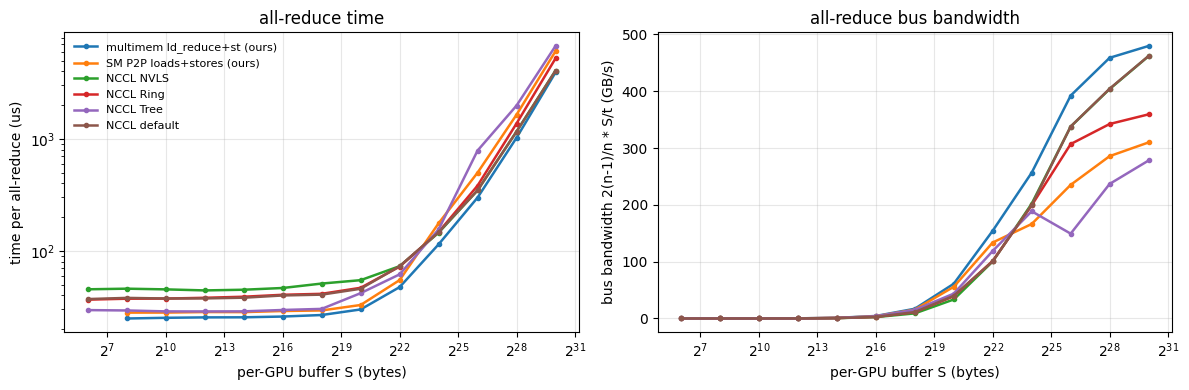

At the largest size (per-GPU link bytes are per all-reduce, divided by S):


variant,size_bytes,time_us,payload_GBps,agg_GBps,link_util,fabric_util,tx_per_S,rx_per_S,exp_tx_per_S,exp_rx_per_S,wrong,nvml_mem_util_pct
multimem_f32,1073741824.000,3918.177,274.041,479.572,0.619,0.619,1.125,1.125,1.125,1.125,0.000,nan
multimem_bf16,1073741824.000,3916.997,274.124,479.717,0.617,0.617,1.125,1.125,1.125,1.125,0.000,nan
multimem_ldreduce_f32,1073741824.000,2981.059,360.188,630.329,0.702,0.702,1.000,0.125,1.000,0.125,0.000,nan
multimem_st_f32,1073741824.000,2888.426,371.739,650.544,0.723,0.723,0.125,1.000,0.125,1.000,0.000,nan
multimem_red_f32,1073741824.000,25567.329,41.997,73.494,0.725,0.725,1.000,8.000,1.000,1.000,0.000,nan
sm_p2p_f32,1073741824.000,6064.414,177.056,309.848,0.644,0.644,1.750,1.750,1.750,1.750,0.000,nan
nccl_auto,1073741824.000,4067.227,263.998,461.997,0.644,0.644,1.125,1.125,nan,nan,0.000,48.038
nccl_ring,1073741824.000,5230.594,205.281,359.242,0.782,0.782,1.750,1.750,nan,nan,0.000,32.536
nccl_tree,1073741824.000,6757.851,158.888,278.054,0.608,0.608,1.750,1.750,nan,nan,0.000,25.369
nccl_nvls,1073741824.000,4069.579,263.846,461.730,0.644,0.644,1.125,1.125,nan,nan,0.000,47.375


Nsight Compute counters per GPU per kernel (bytes divided by S; means over the 8 GPUs):


variant,size_bytes,gpus,gpu_time_us,hbm_read_per_S,hbm_write_per_S,hbm_util,nvl_tx_per_S,nvl_rx_per_S,nvl_protocol_frac,sm_inst_executed,sm_cycles_active
fabric.pair,268435456.000,1,3031.008,0.000,0.000,0.000,4.515,3.615,0.114,25473648.000,691415115.000
packet.store_sparse_s128,1073741824.000,1,1129.632,0.000,0.000,0.000,0.355,0.259,0.667,3394416.000,258867017.000
packet.store_sparse_s32,1073741824.000,1,3361.984,0.000,0.000,0.000,1.254,1.004,0.203,12831600.000,766227826.000
packet.store_w16,268435456.000,1,3028.576,0.000,0.000,0.000,4.515,3.613,0.114,25473648.000,691436867.000
packet.store_w4,268435456.000,1,3076.928,0.000,0.000,0.000,4.540,3.630,0.119,75805296.000,702952962.000
reduce.multimem_f32,1048576.000,8,186.560,0.129,0.000,0.000,0.525,0.574,0.527,92016.000,10916719.375
reduce.multimem_f32,16777216.000,8,222.984,0.125,0.000,0.003,0.502,0.574,0.502,149616.000,49281546.875
reduce.multimem_f32,268435456.000,8,714.876,0.125,0.037,0.018,0.478,0.520,0.481,703344.000,165156497.125
reduce.multimem_ldreduce_f32,16777216.000,8,210.724,0.125,0.000,0.003,0.254,0.297,0.515,161904.000,49203281.625
reduce.multimem_red_f32,16777216.000,8,346.992,2.000,0.023,0.029,2.069,2.350,0.517,1809008.000,78910463.000


In [4]:
rd = df[(df.probe == "reduce") & (df.src == -1)].copy()
rd["tx_per_S"] = rd.nvml_tx_data_bytes / NGPU / rd.iters / rd.size_bytes
rd["rx_per_S"] = rd.nvml_rx_data_bytes / NGPU / rd.iters / rd.size_bytes
rd["exp_tx_per_S"] = rd.note.map(lambda n: float(kv(n)["expected_tx_bytes_per_gpu"])) / rd.size_bytes
rd["exp_rx_per_S"] = rd.note.map(lambda n: float(kv(n)["expected_rx_bytes_per_gpu"])) / rd.size_bytes
nc = df[(df.probe == "nccl") & (df.src == -1)].copy()
nc["tx_per_S"] = nc.nvml_tx_data_bytes / NGPU / nc.iters / nc.size_bytes
nc["rx_per_S"] = nc.nvml_rx_data_bytes / NGPU / nc.iters / nc.size_bytes
nc["variant"] = nc.note.map(lambda n: "nccl_" + kv(n)["nccl_algo"].lower().replace("unset", "auto"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
series = [("multimem_f32", rd, "multimem ld_reduce+st (ours)"), ("sm_p2p_f32", rd, "SM P2P loads+stores (ours)"),
          ("nccl_nvls", nc, "NCCL NVLS"), ("nccl_ring", nc, "NCCL Ring"), ("nccl_tree", nc, "NCCL Tree"), ("nccl_auto", nc, "NCCL default")]
for v, src, lab in series:
    s = src[src.variant == v].sort_values("size_bytes")
    axes[0].plot(s.size_bytes, s.time_us, marker="o", ms=3, lw=1.8, label=lab)
    axes[1].plot(s.size_bytes, s.agg_GBps, marker="o", ms=3, lw=1.8, label=lab)
for ax, yl, t in [(axes[0], "time per all-reduce (us)", "all-reduce time"), (axes[1], "bus bandwidth 2(n-1)/n * S/t (GB/s)", "all-reduce bus bandwidth")]:
    ax.set_xscale("log", base=2); ax.set_xlabel("per-GPU buffer S (bytes)"); ax.set_ylabel(yl); ax.set_title(t); ax.grid(alpha=0.3)
axes[0].set_yscale("log"); axes[0].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

big = pd.concat([rd[rd.size_bytes == rd.size_bytes.max()][["variant", "size_bytes", "time_us", "payload_GBps", "agg_GBps", "link_util", "fabric_util", "tx_per_S", "rx_per_S", "exp_tx_per_S", "exp_rx_per_S", "wrong"]],
                 nc[nc.size_bytes == nc.size_bytes.max()][["variant", "size_bytes", "time_us", "payload_GBps", "agg_GBps", "link_util", "fabric_util", "tx_per_S", "rx_per_S", "nvml_mem_util_pct", "wrong"]]])
print("At the largest size (per-GPU link bytes are per all-reduce, divided by S):")
display(big.style.format(precision=3).hide(axis="index"))

ncu = df[df.probe == "ncu"].copy()
if ncu.hbm_read_bytes.notna().any():
    ncu["hbm_rw_per_S"] = (ncu.hbm_read_bytes + ncu.hbm_write_bytes) / ncu.size_bytes
    ncu["nvl_rx_per_S"] = ncu.nvlrx_bytes / ncu.size_bytes; ncu["nvl_tx_per_S"] = ncu.nvltx_bytes / ncu.size_bytes
    ncu["nvl_protocol_frac"] = ncu.nvltx_protocol_bytes / ncu.nvltx_bytes
    g = ncu.groupby(["variant", "size_bytes"]).agg(gpus=("src", "size"), gpu_time_us=("gpu_time_ns", lambda s: s.mean() / 1e3),
        hbm_read_per_S=("hbm_read_bytes", "mean"), hbm_write_per_S=("hbm_write_bytes", "mean"), hbm_util=("hbm_util", "mean"),
        nvl_tx_per_S=("nvl_tx_per_S", "mean"), nvl_rx_per_S=("nvl_rx_per_S", "mean"), nvl_protocol_frac=("nvl_protocol_frac", "mean"),
        sm_inst_executed=("sm_inst_executed", "mean"), sm_cycles_active=("sm_cycles_active", "mean")).reset_index()
    g["hbm_read_per_S"] /= g.size_bytes; g["hbm_write_per_S"] /= g.size_bytes
    print("Nsight Compute counters per GPU per kernel (bytes divided by S; means over the 8 GPUs):")
    display(g.style.format(precision=3).hide(axis="index"))
else:
    print("ncu rows carry no counters in this run:", ncu.note.unique())

## Q4: do SMs have to drive communication?

`smrole` compares the three ways a GPU can push 1 GiB to a peer: copy engines (`cudaMemcpyPeerAsync`, zero SMs),
plain SM stores/loads with 1..264 blocks, and TMA bulk copies (`cp.async.bulk`, one issuing thread per block).
The `overlap_*` rows run each copy mechanism concurrently with a compute-bound kernel on the same GPU and report
the slowdown of both sides (`_half` variants leave half the SM thread slots free so the copy kernel can co-reside;
the full variants show what happens when compute occupies every SM). The `owner_busy_*` rows read GPU 0's memory
from GPU 1 while GPU 0's SMs are 100 % busy with arithmetic, or while GPU 0 saturates its own HBM.

SM 16-byte stores                       :   371 GB/s max; >=95% of that with 8 blocks (of 132 SMs); 1 block = 46.8 GB/s
SM 16-byte loads (pull)                 :   368 GB/s max; >=95% of that with 132 blocks (of 132 SMs); 1 block = 3.7 GB/s
TMA cp.async.bulk push (1 thread/block) :   371 GB/s max; >=95% of that with 64 blocks (of 132 SMs); 1 block = 30.9 GB/s
copy engines, no SMs: 1 stream(s) 392 GB/s, 2 stream(s) 389 GB/s, 4 stream(s) 385 GB/s, 8 stream(s) 377 GB/s


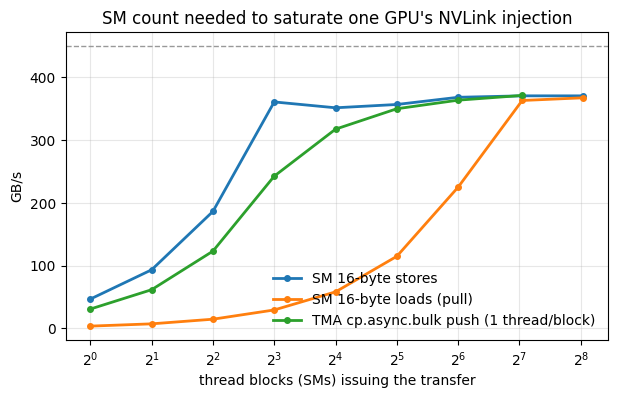

,compute slowdown (x),copy slowdown (x),copy GB/s while overlapped
kind,,,
ce,1.00,1.06,371.87
ce_half,1.00,1.06,372.04
sm32,1.00,76.87,4.65
sm32_half,1.00,52.95,6.74
smfull,1.00,78.71,4.75
tma32,1.00,93.50,3.76
tma32_half,1.00,40.78,8.62


variant,payload_GBps,link_util,note
owner_idle_read,371,0.82,nan
owner_busy_compute_read,373,0.54,owner_kernel=burn;owner_time_us=4321.28041251;owner_outlasted_reader=1
owner_busy_hbm_read,263,0.47,owner_kernel=hbm_stream;owner_time_us=5039.05895292;owner_outlasted_reader=1
owner_busy_compute_ce,391,0.56,owner_kernel=burn;owner_time_us=4125.87677276;owner_outlasted_reader=1
owner_busy_hbm_ce,325,0.47,owner_kernel=hbm_stream;owner_time_us=5032.23597453;owner_outlasted_reader=1


In [5]:
sm = df[df.probe == "smrole"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
for pref, lab in [("sm_store_blocks_", "SM 16-byte stores"), ("sm_load_blocks_", "SM 16-byte loads (pull)"), ("tma_push_blocks_", "TMA cp.async.bulk push (1 thread/block)")]:
    s = sm[sm.variant.str.startswith(pref)].copy(); s["b"] = s.variant.str[len(pref):].astype(int); s = s.sort_values("b")
    ax.plot(s.b, s.payload_GBps, marker="o", ms=4, lw=2, label=lab)
    need = s[s.payload_GBps >= 0.95 * s.payload_GBps.max()].b.min()
    print(f"{lab:40s}: {s.payload_GBps.max():5.0f} GB/s max; >=95% of that with {need} blocks (of {int(gpu.sms.iloc[0])} SMs); 1 block = {s.payload_GBps.iloc[0]:.1f} GB/s")
ce = sm[sm.variant.str.startswith("ce_streams_")]
print("copy engines, no SMs:", ", ".join(f"{int(r.streams)} stream(s) {r.payload_GBps:.0f} GB/s" for _, r in ce.iterrows()))
ax.set_xscale("log", base=2); ax.set_xlabel("thread blocks (SMs) issuing the transfer"); ax.set_ylabel("GB/s"); ax.axhline(LINK_PEAK, color="0.6", ls="--", lw=1)
ax.set_title("SM count needed to saturate one GPU's NVLink injection"); ax.legend(frameon=False); ax.grid(alpha=0.3); plt.show()

ov = sm[sm.variant.str.startswith("overlap_")].copy()
ov["kind"] = ov.variant.str.replace("overlap_", "").str.replace("_copy", "").str.replace("_compute", "")
ov["side"] = np.where(ov.variant.str.endswith("_copy"), "copy", "compute")
ov["slowdown"] = ov.time_us / ov.time_alone_us
t = ov.pivot(index="kind", columns="side", values="slowdown")
t.columns = ["compute slowdown (x)", "copy slowdown (x)"]; t["copy GB/s while overlapped"] = ov[ov.side == "copy"].set_index("kind").payload_GBps
display(t.style.format("{:.2f}"))
ob = sm[sm.variant.str.startswith("owner_")][["variant", "payload_GBps", "link_util", "note"]]
display(ob.style.format({"payload_GBps": "{:.0f}", "link_util": "{:.2f}"}).hide(axis="index"))

## Q5: kernel startup overhead

Each row is 200 (or 1000) launches timed individually with CUDA events on the stream (mean and minimum). The
remote-store and multicast rows are the same measurement for the smallest possible NVLink operation, so the
difference to `empty_kernel_sync` is the fabric's own contribution to startup.

In [6]:
la = df[df.probe == "launch"][["variant", "n_gpus", "size_bytes", "time_us", "time_min_us", "n_ops"]]
display(la.style.format({"time_us": "{:.2f}", "time_min_us": "{:.2f}", "size_bytes": "{:.0f}", "n_ops": "{:.0f}"}).hide(axis="index"))

variant,n_gpus,size_bytes,time_us,time_min_us,n_ops
empty_kernel_sync,1.000000,nan,5.31,4.96,200
empty_kernel_b2b,1.000000,nan,2.32,nan,1000
launch_api_host,1.000000,nan,2.27,2.04,1000
graph_empty,1.000000,nan,4.99,4.67,200
memcpy_peer_1B,2.000000,1,5.30,4.61,200
memcpy_peer_64B,2.000000,64,5.48,4.61,200
memcpy_peer_4096B,2.000000,4096,5.51,4.74,200
memcpy_local_64B,1.000000,64,5.77,5.28,200
store_remote_16B,2.000000,16,5.59,5.28,200
store_local_16B,1.000000,16,5.55,4.96,200


## Summary

(filled in below from the numbers above)

In [7]:
def row(probe, variant):
    r = df[(df.probe == probe) & (df.variant == variant)]
    return r.iloc[0] if len(r) else None
def at_max(frame, variant):
    r = frame[frame.variant == variant]
    return r[r.size_bytes == r.size_bytes.max()].iloc[0] if len(r) else None
s32 = row("packet", "store_sparse_s32"); s128 = row("packet", "store_sparse_s128"); w16 = row("packet", "store_w16"); l32 = row("packet", "load_sparse_s32")
pp = row("packet", "pingpong"); pair = row("fabric", "pair"); perm = fb[(fb.variant == "perm_shift_1") & (fb.src == -1)].iloc[0]
inc7 = fb[(fb.variant == f"incast_{NGPU-1}") & (fb.src == -1)].iloc[0]; a2a = fb[(fb.variant == "all2all") & (fb.src == -1)].iloc[0]
mm = at_max(rd, "multimem_f32"); smp = at_max(rd, "sm_p2p_f32"); nv = at_max(nc, "nccl_nvls"); rg = at_max(nc, "nccl_ring"); tr = at_max(nc, "nccl_tree"); ldr = at_max(rd, "multimem_ldreduce_f32")
S = mm.size_bytes
def need_blocks(pref):
    s = sm[sm.variant.str.startswith(pref)].copy(); s["b"] = s.variant.str[len(pref):].astype(int)
    return int(s[s.payload_GBps >= 0.95 * s.payload_GBps.max()].b.min()), s.payload_GBps.max()
nb_st, bw_st = need_blocks("sm_store_blocks_"); nb_ld, bw_ld = need_blocks("sm_load_blocks_"); nb_tma, bw_tma = need_blocks("tma_push_blocks_")
ce1 = row("smrole", "ce_streams_1")
def slow(kind, side):
    r = row("smrole", f"overlap_{kind}_{side}")
    return (r.time_us / r.time_alone_us) if r is not None else float("nan")
oi = row("smrole", "owner_idle_read"); oc = row("smrole", "owner_busy_compute_read"); oh = row("smrole", "owner_busy_hbm_read")
hbm_line = ""
if ncu.hbm_read_bytes.notna().any():
    def hbm(v):
        g = ncu[(ncu.variant == v) & (ncu.size_bytes == ncu[ncu.variant == v].size_bytes.max())]
        return ((g.hbm_read_bytes + g.hbm_write_bytes).mean() / g.size_bytes.iloc[0], g.hbm_util.mean(), g.sm_inst_executed.mean(), g.size_bytes.iloc[0])
    m = hbm("reduce.multimem_f32"); p = hbm("reduce.sm_p2p_f32")
    hbm_line = (f"\n    HBM (ncu, per GPU, S={m[3]/2**20:.0f} MiB): multimem reads+writes {m[0]:.2f} S at {m[1]:.0%} of HBM peak with {m[2]:.2e} warp-instructions;"
                f" SM P2P {p[0]:.2f} S at {p[1]:.0%} with {p[2]:.2e} warp-instructions.")
print(f"""Q1  Smallest unit the link carries for one isolated 4-byte store: {s128.wire_bytes_per_op:.0f} B (stride >= 128 B), {s32.wire_bytes_per_op:.0f} B when 4 stores share a 128-B line;
    a 4-byte remote load always moves {l32.wire_bytes_per_op:.0f} B. Protocol overhead raw/data = {w16.nvml_tx_raw_bytes/w16.nvml_tx_data_bytes:.2f} for full packets,
    {s128.nvml_tx_raw_bytes/s128.nvml_tx_data_bytes:.2f} for 16-B packets. One-way remote-write latency {pp.time_us:.2f} us (see the size-sweep printout for the alpha/beta knee).
Q2  One pair: {pair.agg_GBps:.0f} GB/s (SM stores). All {NGPU} GPUs sending at once (perm_shift_1): {perm.agg_GBps:.0f} GB/s aggregate = {perm.agg_GBps/NGPU:.0f} GB/s each,
    all-to-all: {a2a.agg_GBps/NGPU:.0f} GB/s each -> every one of the {NGPU}x{int(gpu.nvlinks.iloc[0])} inbound links is saturated simultaneously ({perm.fabric_util:.0%} of {NGPU} x {LINK_PEAK:.0f} GB/s);
    {NGPU-1} senders into one GPU get {inc7.agg_GBps:.0f} GB/s total (the receiver's 18 links, not the switch, are the cap). Per-link byte balance within 0.5 %.
Q3  Yes: switch-side reduction. multimem all-reduce at S={S/2**20:.0f} MiB: {mm.time_us:.0f} us ({mm.payload_GBps:.0f} GB/s algbw, {mm.agg_GBps:.0f} busbw), correct ({int(mm.wrong)} wrong);
    per-GPU link bytes tx/rx = {mm.tx_per_S:.3f}/{mm.rx_per_S:.3f} S (theory 1.125: each GPU sends its data once and receives its chunk already reduced -> rx/S={ldr.rx_per_S:.3f} for the
    reduce-scatter half alone), vs {smp.tx_per_S:.2f} S for the SM-driven P2P all-reduce ({smp.time_us:.0f} us). NCCL: NVLS {nv.time_us:.0f} us ({nv.tx_per_S:.3f} S), Ring {rg.time_us:.0f} us ({rg.tx_per_S:.2f} S),
    Tree {tr.time_us:.0f} us; link util {mm.link_util:.0%} (multimem) / {nv.link_util:.0%} (NVLS) / {rg.link_util:.0%} (Ring); NVML memory-controller busy: NVLS {nv.nvml_mem_util_pct:.0f} %, Ring {rg.nvml_mem_util_pct:.0f} %.{hbm_line}
Q4  Copy engines: {ce1.payload_GBps:.0f} GB/s with zero SMs. SM stores: 1 block {row('smrole','sm_store_blocks_1').payload_GBps:.0f} GB/s, {nb_st} blocks reach 95 % of {bw_st:.0f} GB/s; SM loads need {nb_ld} blocks (95 % of {bw_ld:.0f});
    TMA cp.async.bulk from ONE issuing thread per block: 1 block {row('smrole','tma_push_blocks_1').payload_GBps:.0f} GB/s, {nb_tma} blocks reach 95 % of {bw_tma:.0f} GB/s (SMs delegate the movement to the TMA unit).
    Compute filling every SM slows the copy by: CE {slow('ce','copy'):.2f}x, SM(32 blocks) {slow('sm32','copy'):.1f}x, TMA(32) {slow('tma32','copy'):.1f}x; with half the SM slots free: CE {slow('ce_half','copy'):.2f}x, SM {slow('sm32_half','copy'):.2f}x, TMA {slow('tma32_half','copy'):.2f}x
    (compute side: {slow('ce','compute'):.2f}x / {slow('sm32','compute'):.2f}x / {slow('tma32','compute'):.2f}x). Reading a GPU whose SMs are 100 % busy: {oc.payload_GBps:.0f} GB/s vs {oi.payload_GBps:.0f} idle (owner SMs not needed);
    with the owner saturating its own HBM: {oh.payload_GBps:.0f} GB/s (HBM, not SMs, is the contended resource).
Q5  Empty kernel {row('launch','empty_kernel_sync').time_us:.1f} us (event-timed), {row('launch','empty_kernel_b2b').time_us:.1f} us back-to-back, host launch call {row('launch','launch_api_host').time_us:.1f} us, graph {row('launch','graph_empty').time_us:.1f} us;
    1-byte peer copy {row('launch','memcpy_peer_1B').time_us:.1f} us; 16-byte remote store kernel {row('launch','store_remote_16B').time_us:.1f} us; 16-byte multicast reduce {row('launch','multimem_ldreduce_16B').time_us:.1f} us.""")

Q1  Smallest unit the link carries for one isolated 4-byte store: 16 B (stride >= 128 B), 32 B when 4 stores share a 128-B line;
    a 4-byte remote load always moves 32 B. Protocol overhead raw/data = 1.13 for full packets,
    3.00 for 16-B packets. One-way remote-write latency 2.34 us (see the size-sweep printout for the alpha/beta knee).
Q2  One pair: 370 GB/s (SM stores). All 8 GPUs sending at once (perm_shift_1): 2928 GB/s aggregate = 366 GB/s each,
    all-to-all: 349 GB/s each -> every one of the 8x18 inbound links is saturated simultaneously (80% of 8 x 450 GB/s);
    7 senders into one GPU get 377 GB/s total (the receiver's 18 links, not the switch, are the cap). Per-link byte balance within 0.5 %.
Q3  Yes: switch-side reduction. multimem all-reduce at S=1024 MiB: 3918 us (274 GB/s algbw, 480 busbw), correct (0 wrong);
    per-GPU link bytes tx/rx = 1.125/1.125 S (theory 1.125: each GPU sends its data once and receives its chunk already reduced -> rx/S=0.125 for the
    reduc